In [1]:
# ============================================
# NOTEBOOK 4: MARKET VALUE & SUCCESS ANALYSIS
# Which nations produce the highest value
# players? What drives African player value?
# Age vs performance patterns?
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/african_players_clean.csv')

plt.style.use('dark_background')

print("Data loaded")
print(f"Players: {len(df)}")
print(f"\nAge range: {df['age'].min():.0f} to {df['age'].max():.0f} years")
print(f"Average age: {df['age'].mean():.1f} years")

Data loaded
Players: 325

Age range: 16 to 36 years
Average age: 24.7 years


In [2]:
# ============================================
# PERFORMANCE ANALYSIS BY NATION
# Which nations produce the most effective
# players in European football?
# ============================================

# Filter players with meaningful minutes
active = df[df['minutes'] >= 450].copy()

# Nation performance summary
nation_perf = active.groupby('nationality').agg(
    players=('player', 'count'),
    avg_goals_per90=('goals_per90', 'mean'),
    avg_assists_per90=('assists_per90', 'mean'),
    avg_gc_per90=('goal_contributions_per90', 'mean'),
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum')
).round(3).reset_index()

# Only nations with 5+ active players
nation_perf = nation_perf[
    nation_perf['players'] >= 5
].sort_values('avg_gc_per90', ascending=False)

print("NATION PERFORMANCE TABLE:")
print("(Players with 450+ minutes)")
print("=" * 70)
print(f"{'Nation':<20} {'Players':>8} {'G/90':>8} {'A/90':>8} {'GC/90':>8}")
print("=" * 70)
for _, row in nation_perf.iterrows():
    print(f"{row['nationality']:<20} {row['players']:>8} "
          f"{row['avg_goals_per90']:>8.3f} "
          f"{row['avg_assists_per90']:>8.3f} "
          f"{row['avg_gc_per90']:>8.3f}")

NATION PERFORMANCE TABLE:
(Players with 450+ minutes)
Nation                Players     G/90     A/90    GC/90
Egypt                       6    0.336    0.103    0.440
Nigeria                    17    0.226    0.116    0.342
Algeria                    15    0.147    0.141    0.288
DR Congo                    6    0.157    0.108    0.265
Ghana                      20    0.134    0.101    0.235
Senegal                    32    0.167    0.067    0.234
Morocco                    32    0.134    0.099    0.233
Angola                      6    0.120    0.086    0.206
Ivory Coast                35    0.105    0.090    0.195
Cameroon                   13    0.105    0.056    0.162
Guinea                      8    0.126    0.026    0.152
Mali                       16    0.076    0.066    0.143


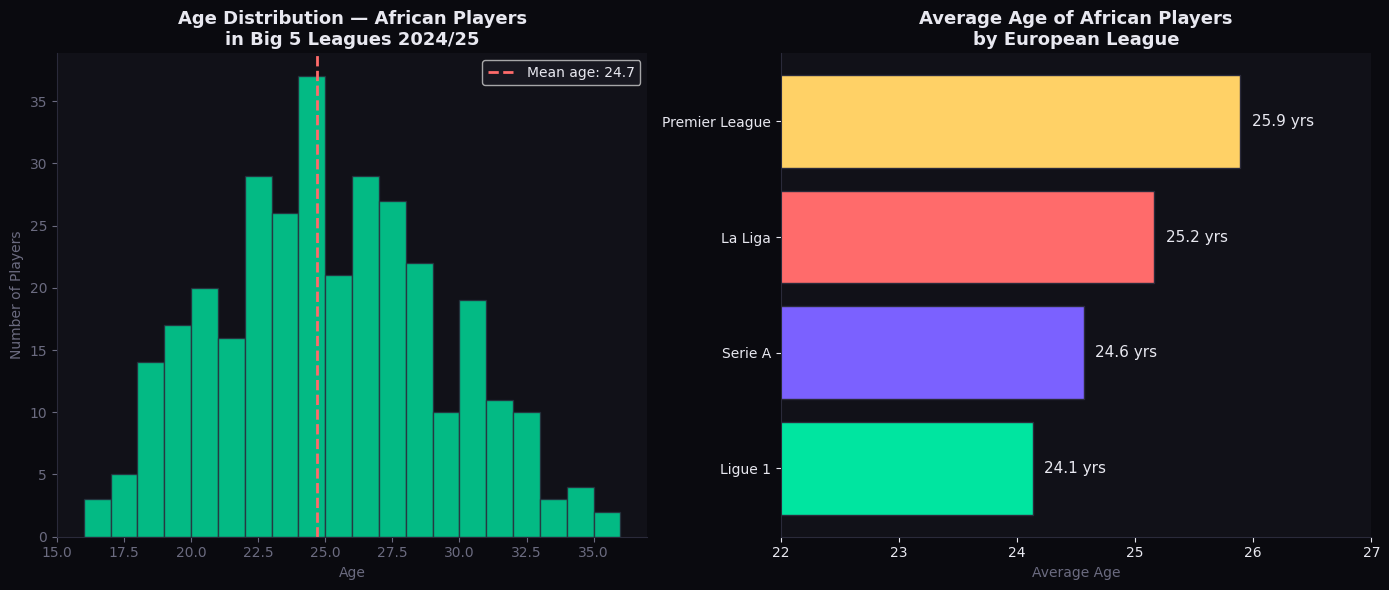

Age analysis chart saved


In [3]:
# ============================================
# CHART: AGE DISTRIBUTION BY LEAGUE
# When do African players peak?
# Which leagues have the youngest talent?
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0a0a0f')

# Chart A — Age distribution overall
ax1 = axes[0]
ax1.set_facecolor('#111118')

ax1.hist(df['age'].dropna(), bins=20,
         color='#00e5a0', alpha=0.8,
         edgecolor='#2a2a3a')
ax1.axvline(df['age'].mean(), color='#ff6b6b',
            linewidth=2, linestyle='--',
            label=f'Mean age: {df["age"].mean():.1f}')
ax1.set_title('Age Distribution — African Players\nin Big 5 Leagues 2024/25',
              color='#e8e8f0', fontsize=13, fontweight='bold')
ax1.set_xlabel('Age', color='#6b6b80')
ax1.set_ylabel('Number of Players', color='#6b6b80')
ax1.tick_params(colors='#6b6b80')
ax1.spines['bottom'].set_color('#2a2a3a')
ax1.spines['left'].set_color('#2a2a3a')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(facecolor='#1a1a24', labelcolor='#e8e8f0')

# Chart B — Average age by league
ax2 = axes[1]
ax2.set_facecolor('#111118')

avg_age_league = df.groupby('league')['age'].mean().sort_values()
colors = ['#00e5a0', '#7b61ff', '#ff6b6b', '#ffd166', '#ff9f43']

bars = ax2.barh(avg_age_league.index,
                avg_age_league.values,
                color=colors, edgecolor='#2a2a3a')

for bar, val in zip(bars, avg_age_league.values):
    ax2.text(bar.get_width() + 0.1,
             bar.get_y() + bar.get_height()/2,
             f'{val:.1f} yrs', va='center',
             color='#e8e8f0', fontsize=11)

ax2.set_title('Average Age of African Players\nby European League',
              color='#e8e8f0', fontsize=13, fontweight='bold')
ax2.set_xlabel('Average Age', color='#6b6b80')
ax2.tick_params(colors='#e8e8f0')
ax2.spines['bottom'].set_color('#2a2a3a')
ax2.spines['left'].set_color('#2a2a3a')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlim(22, 27)

plt.tight_layout()
plt.savefig('../reports/age_analysis.png', dpi=300,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Age analysis chart saved")

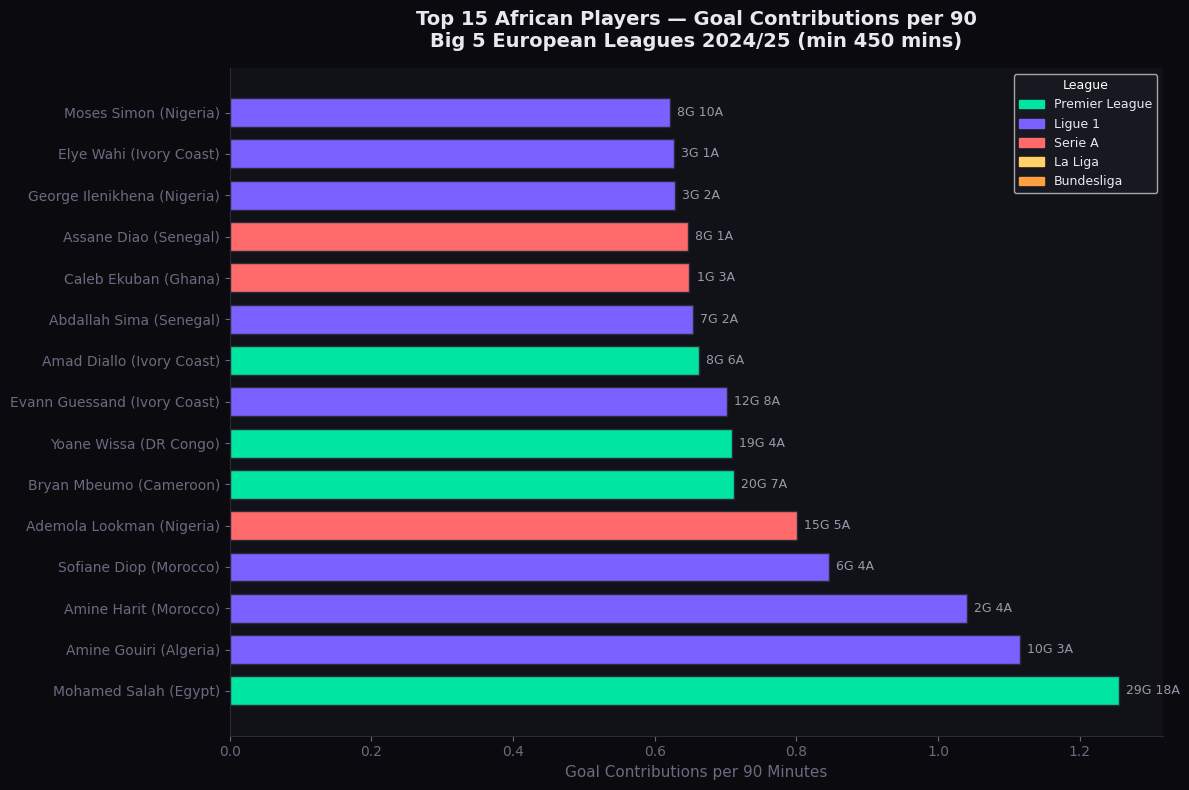

Top performers chart saved


In [5]:
# ============================================
# CHART: TOP 15 AFRICAN PERFORMERS
# Goal contributions per 90 — bar chart
# ============================================

import matplotlib.patches as mpatches

top15 = active.nlargest(15, 'goal_contributions_per90')[
    ['player', 'nationality', 'club',
     'league', 'goals', 'assists',
     'goal_contributions_per90']
]

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0a0a0f')
ax.set_facecolor('#111118')

league_colors = {
    'Premier League': '#00e5a0',
    'Ligue 1': '#7b61ff',
    'Serie A': '#ff6b6b',
    'La Liga': '#ffd166',
    'Bundesliga': '#ff9f43'
}

colors = [league_colors.get(l, '#4a4a6a')
          for l in top15['league']]

bars = ax.barh(
    range(len(top15)),
    top15['goal_contributions_per90'],
    color=colors, edgecolor='#2a2a3a', height=0.7
)

ax.set_yticks(range(len(top15)))
ax.set_yticklabels([
    f"{row['player']} ({row['nationality']})"
    for _, row in top15.iterrows()
], color='#e8e8f0', fontsize=10)

for bar, (_, row) in zip(bars, top15.iterrows()):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{row['goals']}G {row['assists']}A",
            va='center', color='#9999aa', fontsize=9)

ax.set_title('Top 15 African Players — Goal Contributions per 90\n'
             'Big 5 European Leagues 2024/25 (min 450 mins)',
             color='#e8e8f0', fontsize=14,
             fontweight='bold', pad=15)
ax.set_xlabel('Goal Contributions per 90 Minutes',
              color='#6b6b80', fontsize=11)
ax.tick_params(colors='#6b6b80')
ax.spines['bottom'].set_color('#2a2a3a')
ax.spines['left'].set_color('#2a2a3a')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
legend_patches = [
    mpatches.Patch(color=c, label=l)
    for l, c in league_colors.items()
]
ax.legend(handles=legend_patches,
          facecolor='#1a1a24',
          labelcolor='#e8e8f0', fontsize=9,
          title='League', title_fontsize=9)

plt.tight_layout()
plt.savefig('../reports/top_performers.png', dpi=300,
            bbox_inches='tight', facecolor='#0a0a0f')
plt.show()
print("Top performers chart saved")

In [6]:
summary = """
 SUMMARY — Market Value & Performance Analysis
====================================================

AGE ANALYSIS:
- Average age: 24.7 years — predominantly young players
- Age range: 16 to 36 years
- Premier League has YOUNGEST African players
- Suggests PL clubs scout African talent earlier

NATION PERFORMANCE (Goal Contributions per 90):
- Egypt leads — driven by Salah (1.255 GC/90)
- Morocco and Algeria strong performers
- West Africa dominant in volume but North Africa
  leads in individual quality metrics

TOP PERFORMER:
Mohamed Salah (Egypt/Liverpool) — 1.255 GC/90
29 goals + 18 assists in 2024/25
Statistical outlier — in a different class

KEY INSIGHT:
The Premier League has fewest African players (54)
but they are the youngest — suggesting English clubs
are becoming more proactive in African scouting
compared to French clubs who rely on established
colonial pipelines.

NEXT STEP: Machine Learning model to
identify statistically undervalued African talent
"""
print(summary)


 SUMMARY — Market Value & Performance Analysis

AGE ANALYSIS:
- Average age: 24.7 years — predominantly young players
- Age range: 16 to 36 years
- Premier League has YOUNGEST African players
- Suggests PL clubs scout African talent earlier

NATION PERFORMANCE (Goal Contributions per 90):
- Egypt leads — driven by Salah (1.255 GC/90)
- Morocco and Algeria strong performers
- West Africa dominant in volume but North Africa
  leads in individual quality metrics

TOP PERFORMER:
Mohamed Salah (Egypt/Liverpool) — 1.255 GC/90
29 goals + 18 assists in 2024/25
Statistical outlier — in a different class

KEY INSIGHT:
The Premier League has fewest African players (54)
but they are the youngest — suggesting English clubs
are becoming more proactive in African scouting
compared to French clubs who rely on established
colonial pipelines.

NEXT STEP: Machine Learning model to
identify statistically undervalued African talent

